### Célula 1: Imports e Conexão

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
conn = sqlite3.connect("../data/processed/olist.db")

### Célula 2:  Visão geral dos dados

In [2]:
orders   = pd.read_sql("SELECT * FROM orders", conn)
items    = pd.read_sql("SELECT * FROM order_items", conn)
customers= pd.read_sql("SELECT * FROM customers", conn)

print(f"Pedidos:  {len(orders):,}")
print(f"Itens:    {len(items):,}")
print(f"Clientes: {len(customers):,}")
orders.head()

Pedidos:  99,441
Itens:    112,650
Clientes: 99,441


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Célula 3:  KPIs principais:

In [3]:
query = """
SELECT
    COUNT(DISTINCT o.order_id)                       AS total_pedidos,
    COUNT(DISTINCT o.customer_id)                    AS clientes_unicos,
    ROUND(SUM(oi.price + oi.freight_value), 2)       AS receita_total,
    ROUND(AVG(oi.price + oi.freight_value), 2)       AS ticket_medio
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
"""
pd.read_sql(query, conn)

,total_pedidos,clientes_unicos,receita_total,ticket_medio
0,96478,96478,15419773.75,139.93


### Célula 4:  Sazonalidade mensal

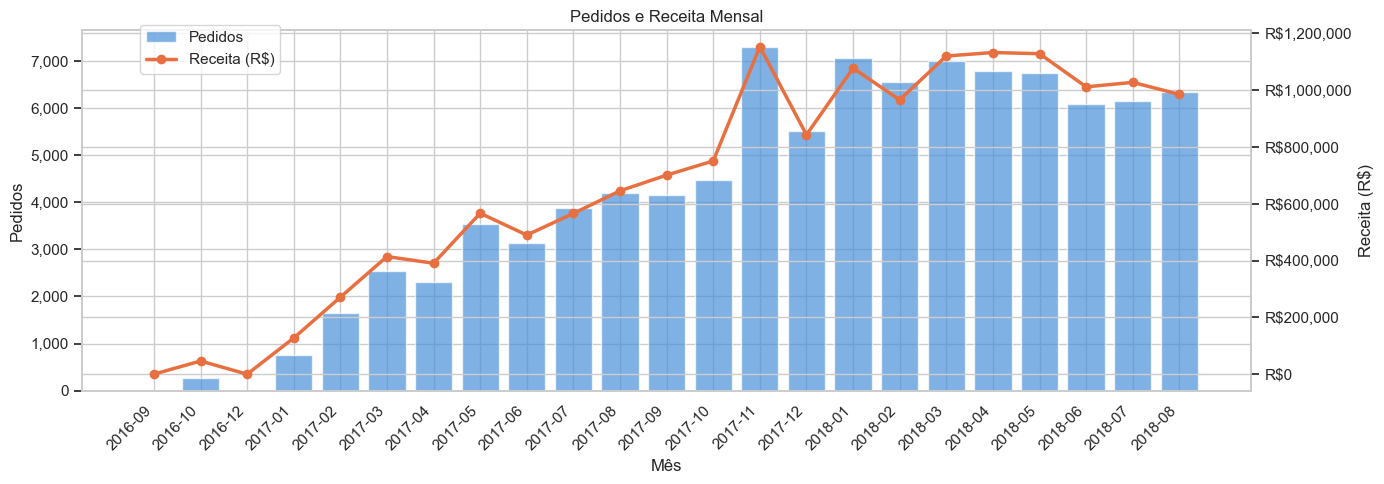

In [5]:
query = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS mes,
    COUNT(DISTINCT o.order_id)                    AS pedidos,
    ROUND(SUM(oi.price + oi.freight_value), 2)    AS receita
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY 1 ORDER BY 1
"""
df_mes = pd.read_sql(query, conn)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

x = range(len(df_mes))

ax1.bar(x, df_mes["pedidos"], color="#4A90D9", alpha=0.7, label="Pedidos")
ax2.plot(x, df_mes["receita"], color="#E87040", linewidth=2.5, marker="o", label="Receita (R$)")

ax1.set_xticks(list(x))
ax1.set_xticklabels(df_mes["mes"], rotation=45, ha="right")
ax1.set_xlabel("Mês")
ax1.set_ylabel("Pedidos")
ax2.set_ylabel("Receita (R$)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.95))
plt.title("Pedidos e Receita Mensal")
plt.tight_layout()
plt.savefig("../reports/01_sazonalidade.png", dpi=150)
plt.show()

### Célula 5:  Top 10 estados

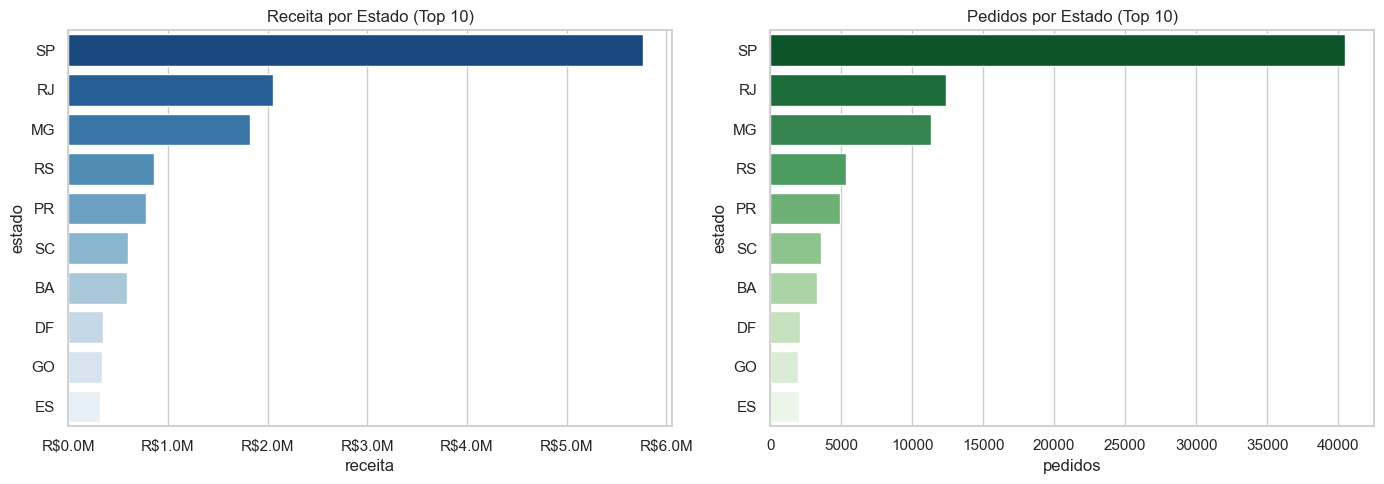

In [11]:
query = """
SELECT
    c.customer_state                             AS estado,
    COUNT(DISTINCT o.order_id)                   AS pedidos,
    ROUND(SUM(oi.price + oi.freight_value), 2)   AS receita
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN customers c    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY 1 ORDER BY receita DESC LIMIT 10
"""
df_estado = pd.read_sql(query, conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df_estado, y="estado", x="receita", hue = "estado", ax=axes[0], palette="Blues_r", legend=False)
axes[0].set_title("Receita por Estado (Top 10)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))

sns.barplot(data=df_estado, y="estado", x="pedidos", hue="estado", ax=axes[1], palette="Greens_r", legend=False)
axes[1].set_title("Pedidos por Estado (Top 10)")

plt.tight_layout()
plt.savefig("../reports/01_estados.png", dpi=150)
plt.show()

## 💡 Insights acionáveis

1. **Sazonalidade**: pico em novembro (Black Friday) com queda acentuada em janeiro
   → Oportunidade de campanhas de reativação no início do ano

2. **Concentração geográfica**: SP e RJ representam ~50% da receita
   → Potencial alto de expansão nos estados do Sul e Centro-Oeste

3. **Ticket médio**: variação significativa entre categorias
   → Estratégia de bundling pode aumentar valor por pedido

### Célula 6:  Encerra conexão

In [13]:
conn.close()
print("✅ Notebook 01 concluído — gráficos salvos em reports/")

✅ Notebook 01 concluído — gráficos salvos em reports/
